## Question 12 — Illumination correction with homomorphic filtering (`sapphire.jpg`)

Model: $f(x,y)=i(x,y)\,r(x,y)$ with **illumination** $i$ and **reflectance** $r$.

### (a) Significance of the multiplicative model

- **Physical motivation:** Light **multiplies** surface properties: the amount of light **reaching** a patch (illumination) scales the **intrinsic** appearance (reflectance/albedo). This matches how imaging sensors integrate **irradiance** and **reflectance** in many simple scenes.
- **Scale separation (informal):** $i$ is usually **slowly varying** (shadows, lighting falloff, vignetting) while $r$ carries **fine detail** (texture, edges). The product ties **low-frequency shading** to **higher-frequency scene content**.
- **Why it matters for correction:** If shading were **additive**, a simple offset would suffice; **multiplicative** shading suggests **logarithms** and **relative** (ratio) correction in linear-light space—motivating homomorphic filtering.

### (b) Logarithm to separate illumination and reflectance

Assume $i,r>0$ (strict positivity can be enforced by a small offset before $\log$).

$$\ln f = \ln i + \ln r.$$

In the **log domain**, the **product becomes a sum**. Illumination $i$ varies slowly in space, so $\ln i$ is **mostly low frequency**; reflectance changes (edges, texture) contribute **more high-frequency** content to $\ln r$. A **linear filter** in the log domain can therefore **emphasize** frequencies associated with $\ln r$ and **de-emphasize** those associated with $\ln i$, approximately **separating** their effects before exponentiating back.

### (c) Homomorphic filtering — algorithm / pseudo-code

**Input:** image $f$, cutoff $D_0$, parameters $\gamma_L,\gamma_H, c$ (filter shape).  
**Output:** illumination-compensated image.

```text
1. Convert to floating point; optionally work on luminance (e.g. L in Lab) to limit color artifacts.
2. f_eps = max(f, small_constant)   // avoid log(0)
3. z = log(f_eps)                    // log transform
4. Z = FFT2(z); apply fftshift for centered spectrum
5. Build radial frequency distance D(u,v) from spectrum center
6. H(u,v) = (gamma_H - gamma_L) * (1 - exp(-c * (D^2 / D0^2))) + gamma_L
         // high-frequency gain ~ gamma_H, low-frequency gain ~ gamma_L
7. Z_hat = Z * H
8. z_hat = real(IFFT2(ifftshift(Z_hat)))
9. f_hat = exp(z_hat)
10. Normalize f_hat to display range [0, 255]
```

**Notes:** Padding to `getOptimalDFTSize` reduces wrap-around artifacts; cropping to original size before `exp`.

### (d) Homomorphic filtering vs histogram equalization

| | **Histogram equalization** | **Homomorphic filtering** |
|---|---|---|
| **Domain** | Gray-level / global contrast remap (often ignores *why* intensity varies). | Assumes **multiplicative** shading; works in **log + frequency** domain. |
| **Illumination** | No explicit model; can **wreck** local color/light meaning if applied per-channel. | Targets **slowly varying** illumination in $\ln f$. |
| **Best when** | You want **global** contrast spread (e.g. dull but **uniformly** lit image). | **Non-uniform illumination**, **shadows**, **vignetting**, backlit scenes where **reflectance** should be recovered. |

**Prefer homomorphic** when shading is **smooth and multiplicative**; **prefer HE (or CLAHE)** when the issue is mainly **narrow dynamic range** without a clear multiplicative lighting model, or when you need a **simpler** pixel-only operator.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

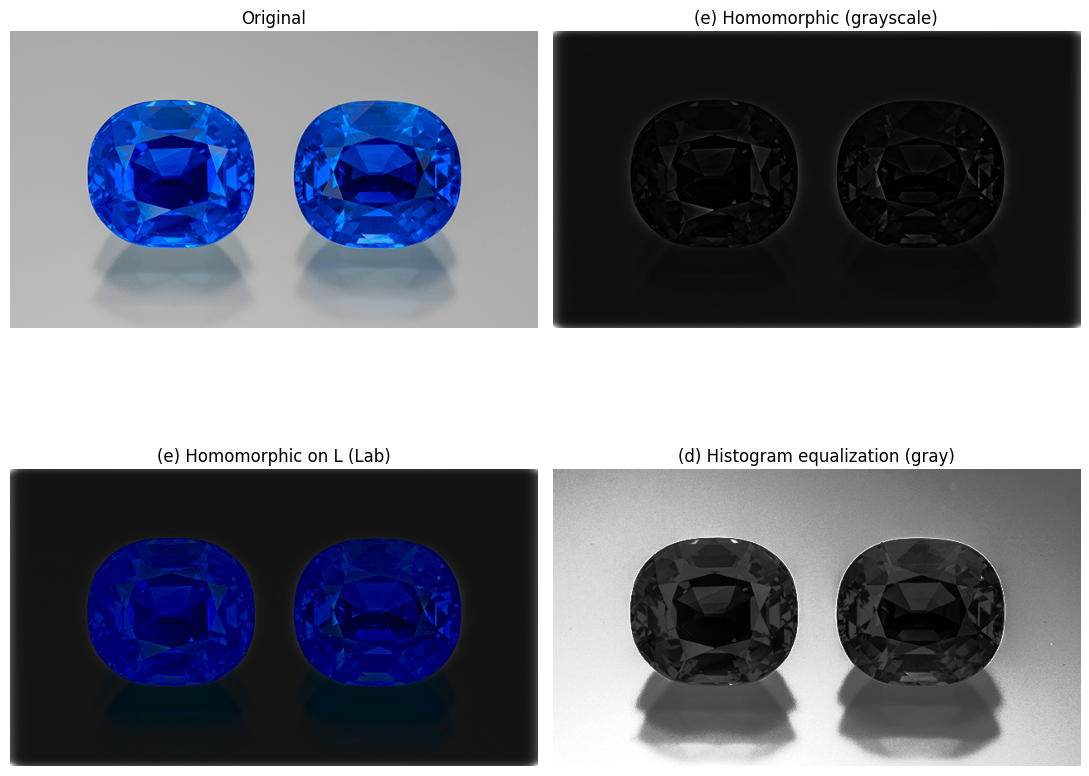

In [2]:
def homomorphic_filter_gray(
    gray: np.ndarray,
    D0: float = 30.0,
    c: float = 2.0,
    gamma_l: float = 0.5,
    gamma_h: float = 2.0,
    eps: float = 1.0,
) -> np.ndarray:
    """Homomorphic filter on uint8 grayscale; returns uint8."""
    g = np.maximum(gray.astype(np.float64), eps)
    z = np.log(g)

    rows, cols = z.shape
    nr = cv2.getOptimalDFTSize(rows)
    nc = cv2.getOptimalDFTSize(cols)
    pad = np.zeros((nr, nc), dtype=np.float64)
    pad[:rows, :cols] = z

    dft = np.fft.fft2(pad)
    dft_s = np.fft.fftshift(dft)

    yy = np.arange(nr, dtype=np.float64) - nr / 2.0
    xx = np.arange(nc, dtype=np.float64) - nc / 2.0
    X, Y = np.meshgrid(xx, yy)
    D = np.sqrt(X * X + Y * Y)
    D[D < 1e-6] = 1e-6

    H = (gamma_h - gamma_l) * (1.0 - np.exp(-c * (D * D) / (D0 * D0))) + gamma_l
    filt = dft_s * H
    z_hat = np.fft.ifft2(np.fft.ifftshift(filt))
    z_hat = np.real(z_hat[:rows, :cols])

    out = np.exp(z_hat)
    out -= out.min()
    out /= out.max() + 1e-12
    return np.clip(np.round(out * 255.0), 0, 255).astype(np.uint8)


def homomorphic_filter_bgr_lab(bgr: np.ndarray, **kwargs) -> np.ndarray:
    """Apply homomorphic filter to L channel only; preserve chroma."""
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    L2 = homomorphic_filter_gray(L, **kwargs)
    return cv2.cvtColor(cv2.merge([L2, a, b]), cv2.COLOR_LAB2BGR)


path = "images/sapphire.jpg"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
hom_gray = homomorphic_filter_gray(gray, D0=25, c=2.0, gamma_l=0.6, gamma_h=2.2)
hom_lab = homomorphic_filter_bgr_lab(bgr, D0=25, c=2.0, gamma_l=0.6, gamma_h=2.2)

he_gray = cv2.equalizeHist(gray)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes[0, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original")
axes[0, 1].imshow(hom_gray, cmap="gray")
axes[0, 1].set_title("(e) Homomorphic (grayscale)")
axes[1, 0].imshow(cv2.cvtColor(hom_lab, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("(e) Homomorphic on L (Lab)")
axes[1, 1].imshow(he_gray, cmap="gray")
axes[1, 1].set_title("(d) Histogram equalization (gray)")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

### (e) Brief comments on `sapphire.jpg` results *(edit after viewing your run)*

- **Illumination correction:** Homomorphic filtering on **L** (or on grayscale) tends to **flatten slow shading**—bright regions are pulled down and darker regions lifted **relative** to each other—so the image looks more **evenly lit** than the original if the scene had **gradient lighting**.
- **Contrast enhancement:** High-frequency content in $\ln f$ is **relatively boosted**, so **edges and texture** can appear **sharper**; global min–max normalization after `exp` stretches display contrast.
- **Artifacts:** Possible **haloing** near strong edges (sharp high-pass in the log domain); **noise amplification** in shadows; **color shifts** if the filter is applied per RGB channel instead of **L only**; **ringing** from FFT padding if parameters are too aggressive. Tuning **$D_0$**, **$c$**, and **$\gamma_L/\gamma_H$** trades shadow lift vs halos.

Adjust `D0`, `c`, `gamma_l`, `gamma_h` in the code cell above to match your image and taste.